In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
%matplotlib inline 
import os 
os.getcwd() 

'C:\\Users\\VINU\\Downloads\\pr2'

In [3]:
df = pd.read_csv("USA_Housing.csv") 
df.head() 

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   str    
dtypes: float64(6), str(1)
memory usage: 499.6 KB


In [5]:
df.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


In [6]:
df.isnull().sum()

Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64

In [7]:
corr = df.corr(numeric_only=True) 

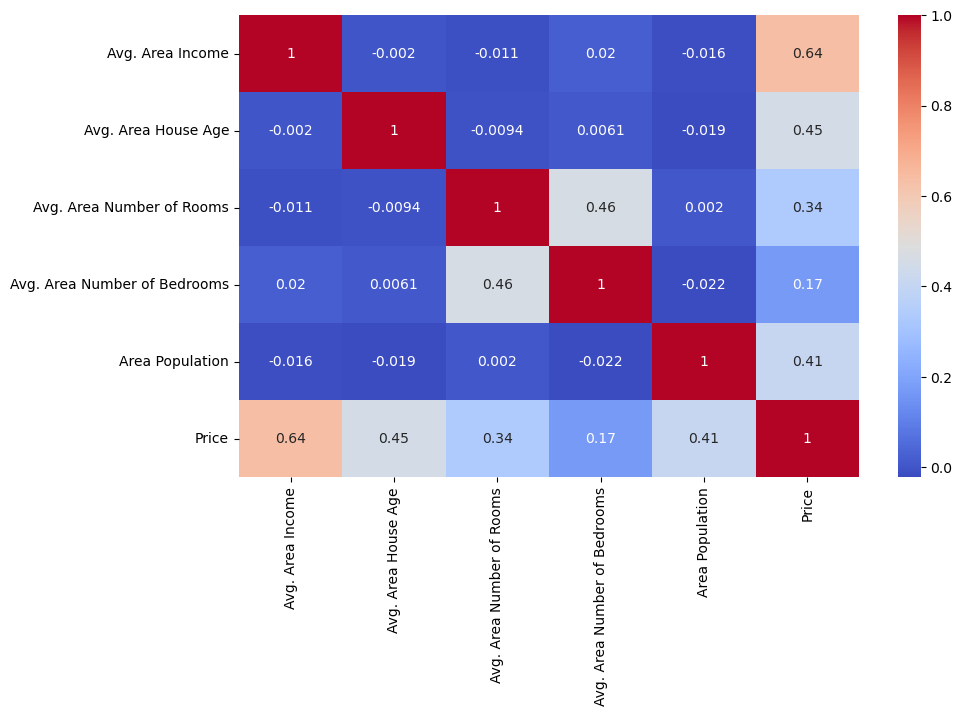

In [8]:
plt.figure(figsize=(10,6)) 
sns.heatmap(corr, annot=True, cmap='coolwarm') 
plt.show() 

In [9]:
X = df[['Avg. Area Income', 
'Avg. Area House Age', 
'Avg. Area Number of Rooms', 
'Avg. Area Number of Bedrooms', 
'Area Population']] 
Y = df['Price'] 

In [10]:
from sklearn.model_selection import train_test_split

# Train-test split
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.3, random_state=42
)

In [11]:
from sklearn.linear_model import LinearRegression 
model = LinearRegression() 
model.fit(X_train, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [12]:
coeff_df = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient']) 
coeff_df

,Coefficient
Avg. Area Income,21.625799
Avg. Area House Age,165590.392746
Avg. Area Number of Rooms,119827.783390
Avg. Area Number of Bedrooms,2361.095262
Area Population,15.216581


In [13]:
predictions = model.predict(X_test) 
predictions[:10]

array([1308536.13592621, 1237122.72746477, 1243835.62817067,
       1229241.7026397 , 1059352.51821892, 1542358.71160874,
       1095210.61602673,  832676.32162672,  788906.33222944,
       1468527.73004814])

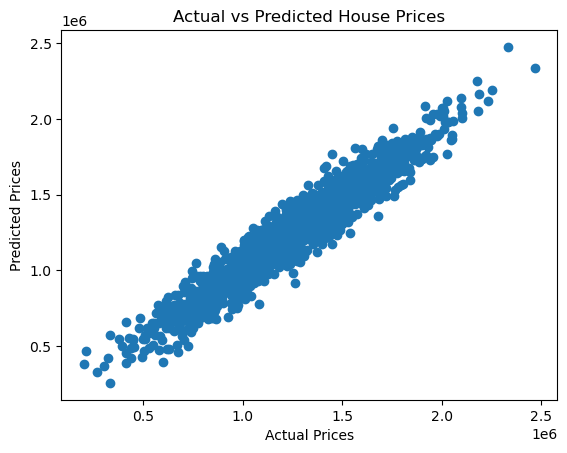

In [14]:
plt.scatter(Y_test, predictions) 
plt.xlabel("Actual Prices") 
plt.ylabel("Predicted Prices") 
plt.title("Actual vs Predicted House Prices") 
plt.show()

In [15]:
from sklearn import metrics 

In [16]:
mae  = metrics.mean_absolute_error(Y_test,  predictions) 
mse = metrics.mean_squared_error(Y_test, predictions) 
rmse = np.sqrt(mse) 
r2 = metrics.r2_score(Y_test, predictions) 
print("MAE:", mae) 
print("MSE:", mse) 
print("RMSE:", rmse) 
print("R2 Score:", r2) 

MAE: 81135.56609336863
MSE: 10068422551.401058
RMSE: 100341.52954485525
R2 Score: 0.9146818498754001
